In [1]:
import sympy as sp

v, theta, Phi = sp.symbols('v theta Phi', positive=True, real=True)

# Energy conservation: v_infty (call it u) depends on v alone.
u = sp.sqrt(v**2 - 2*Phi)

# Local velocity components at fixed v, in terms of theta.
v_par  = v*sp.cos(theta)
v_perp = v*sp.sin(theta)

#   v_inf_par  = u*Q/D,   v_inf_perp = u*N/D
# so tan(theta_infty) = N/Q.
Q    = u*v_par - v_par**2 + Phi
N = (u - v_par)*v_perp
D    = u**2 - u*v_par + Phi

tan_theta_inf = N/Q

d_tan_dtheta      = sp.diff(tan_theta_inf, theta)
cos2_theta_inf     = Q**2 / (Q**2 + N**2)
dtheta_inf_dtheta = sp.simplify(cos2_theta_inf * d_tan_dtheta)

identity_check = sp.simplify(Q**2 + N**2 - D**2)
print("Q^2 + N^2 - D^2 (should be 0):", identity_check)

# Confirm the closed form.
target = 1 + Phi/D
print("dtheta_infty/dtheta - (1 + Phi/D):", sp.simplify(dtheta_inf_dtheta - target))

Q^2 + N^2 - D^2 (should be 0): 0
dtheta_infty/dtheta - (1 + Phi/D): 0


In [2]:
from helper import speed, speedDistGaussian, fv_gaussian
import astropy.constants as acon
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation
from numpy.linalg import norm


rs = 149600000

def grav(x=149600000):
    '''
    Returns potential at a certain distance from the Sun
    @param x The distance from the Sun, in kilometres.
    '''
    return - acon.G.value * 1e-9 * acon.M_sun.value / x

def rotate(t, x):
    '''

    '''
    normal = np.array([-x[1], x[0], 0])
    rot = Rotation.from_rotvec(t * normal / norm(normal))
    r = rot.apply(x)

    return r

def v_inf(v, t, v_c):
    r = rotate(t, v_c)
    r = r / norm(r) * rs
    
    d = np.sqrt(np.sum(v*v) + 2 * grav())

    vi = d * d * v \
        -  d * r / speed(r) * grav(r) \
        - d * v * (np.dot(v, r.T / speed(r)))
    
    vi = vi / (d*d - grav(r) - d * np.dot(v, r.T / speed(r)))
    
    return vi

In [3]:
# -----------------------------------------------------------------
# The focusing map v_infty[v], as given in Alenazi & Gondolo (2006)
# / Lee et al. (2014):
#
#   v_infty[v] = [v_inf^2 v + v_inf*Phi*rhat - v_inf*v*(v.rhat)]
#                / [v_inf^2 + Phi - v_inf*(v.rhat)]
#
# with v_inf^2 = |v|^2 - 2*Phi  (energy conservation), and
# Phi = G*M_sun / r.
# -----------------------------------------------------------------

def v_infty_vec(v, Phi, rhat):
    """Evaluate the focusing map for a local velocity vector v."""
    v = np.asarray(v, dtype=float)
    v2 = np.dot(v, v)
    u = np.sqrt(v2 - 2*Phi)          # = v_infty (speed at infinity)
    vdotr = np.dot(v, rhat)
    D = u**2 + Phi - u*vdotr
    return (u**2*v + u*Phi*rhat - u*v*vdotr) / D


def jacobian_finite_difference(v, Phi, rhat, h=1e-5):
    """Full 3x3 Cartesian Jacobian of v_infty_vec at v, via central
    finite differences (more accurate than forward differences,
    and cheap enough here that there's no reason not to use it)."""
    J = np.zeros((3, 3))
    for i in range(3):
        dv = np.zeros(3)
        dv[i] = h
        plus = v_infty_vec(v + dv, Phi, rhat)
        minus = v_infty_vec(v - dv, Phi, rhat)
        J[:, i] = (plus - minus) / (2*h)
    return J


def jacobian_closed_form(v, Phi, rhat):
    """The derived closed-form result: |dv_infty/dv| = 1 - (Phi/D)^2."""
    v = np.asarray(v, dtype=float)
    v2 = np.dot(v, v)
    u = np.sqrt(v2 - 2*Phi)
    vdotr = np.dot(v, rhat)
    D = u**2 + Phi - u*vdotr
    return np.abs(1 - (Phi/D)**2)


# -----------------------------------------------------------------
# Run the check at several random test points, at a fixed field
# point (r = 1 AU, so Phi = GM_sun/r ~ 887 km^2/s^2), with a
# few different orientations of rhat to make sure nothing was
# accidentally special about a particular choice of axis.
# -----------------------------------------------------------------
if __name__ == "__main__":
    Phi = 887.13   # km^2/s^2, GM_sun/r at 1 AU

    rng = np.random.default_rng(seed=42)
    print(f"{'v (km/s)':>28}   {'rhat':>20}   {'FD Jacobian':>12}   {'Closed form':>12}   {'rel. error':>10}")
    print("-"*100)

    err = []
    jac = []

    n_checks = 1000
    for _ in range(n_checks):
        # random rhat direction (unit vector)
        rhat = rng.normal(size=3)
        rhat /= np.linalg.norm(rhat)

        # random local velocity, large enough in magnitude that
        # v^2 > 2*Phi (unbound orbit) is guaranteed
        v = rng.normal(scale=150, size=3)
        v += rhat * 250   # bias towards a physically sensible speed
        if np.dot(v, v) <= 2*Phi:
            continue

        J_fd = jacobian_finite_difference(v, Phi, rhat, h=1e-4)
        detJ_fd = np.abs(np.linalg.det(J_fd))
        J_closed = jacobian_closed_form(v, Phi, rhat)

        rel_err = abs(detJ_fd - J_closed) / abs(J_closed)

        err.append(rel_err)
        jac.append((J_closed, detJ_fd))

        v_str = np.array2string(v, precision=1, suppress_small=True)
        r_str = np.array2string(rhat, precision=2, suppress_small=True)
        print(f"{v_str:>28}   {r_str:>20}   {detJ_fd:12.8f}   {J_closed:12.8f}   {rel_err:10.2e}")

    print("\nIf the relative errors above are all ~1e-8 or smaller, the closed form is confirmed.")

                    v (km/s)                   rhat    FD Jacobian    Closed form   rel. error
----------------------------------------------------------------------------------------------------
      [ 198.9 -489.9  -53. ]    [ 0.23 -0.79  0.57]     0.99983163     0.99983163     1.15e-09
         [-34.4 -99.6 104.4]    [ 0.37 -0.93 -0.05]     0.99293257     0.99293257     2.00e-10
      [-115.4  285.9  -48.2]       [0.05 0.92 0.38]     0.99845668     0.99845668     5.29e-10
         [142.1 169.5 -74.6]    [ 0.98 -0.06 -0.21]     0.99810169     0.99810169     6.45e-10
         [-84.5 -52.6 237.8]    [-0.56 -0.46  0.69]     0.97469508     0.97469508     8.65e-10
         [117.   47.  112.2]    [ 0.96 -0.18 -0.23]     0.99645223     0.99645223     2.70e-10
         [ 73.5 -66.1 -92.8]    [-0.1  -0.71 -0.7 ]     0.95128858     0.95128858     1.33e-10
      [-200.1  212.    74.4]    [-0.93  0.32  0.16]     0.99205993     0.99205993     1.94e-09
      [ 323.7 -195.8   49.6]       [0.92 0.0

/tmp/ipykernel_9144/721141667.py:5: RuntimeWarning: invalid value encountered in sqrt
  u = np.sqrt(v2 - 2*Phi)


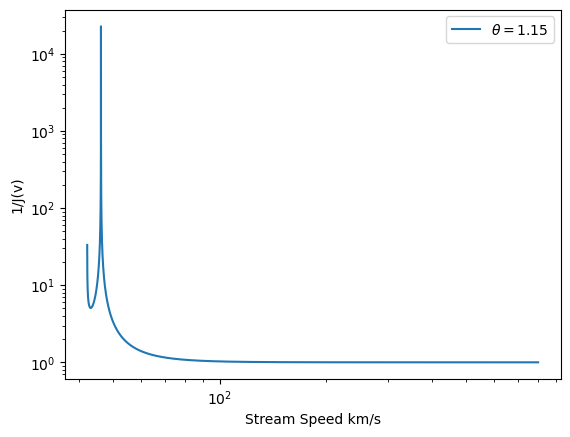

In [4]:
def jacobian_closed_form(v, Phi, theta):
    """The derived closed-form result: |dv_infty/dv| = 1 - (Phi/D)^2."""
    #v = np.asarray(v, dtype=float)
    v2 = v*v #np.dot(v, v)
    u = np.sqrt(v2 - 2*Phi)
    vdotr = v * np.cos(theta) #np.dot(v, rhat)
    D = u**2 + Phi - u*vdotr
    return np.abs(1 - (Phi/D)**2)


Phi = 887.13
t = 1.152621404201767
v = np.linspace(np.sqrt(2*Phi), 800, 100000)
jac = jacobian_closed_form(v, Phi, t)

plt.clf()
plt.loglog(v, 1/ jac, label = f"$\\theta = {t:.2f}$")

plt.xlabel("Stream Speed km/s")
plt.ylabel("1/J(v)")
plt.legend()


In [5]:
import astropy.constants as acon
from helper import *

def grav(x):
    return - acon.G.value * 1e-9 * acon.M_sun.value / 149600000

def v_inf(v):
    r = np.array([[1, 0, 0]]) # in km
    d = np.sqrt(np.sum(v*v) + 2 * grav(r))

    vi = d * d * v \
        -  d * r / speed(r) * grav(r) \
        - d * v * (np.dot(v, r.T / speed(r)))
    
    vi = vi / (d*d - grav(r) - d * np.dot(v, r.T / speed(r)))
    
    return vi

def func(v, vi):
    return (v_inf(v) - vi).T[:, 0]

phi = np.linspace(-np.pi, np.pi, 500)
vel = [np.cos(phi), np.sin(phi), np.zeros_like(phi)]
spd = 20
vel = np.column_stack(vel) #arbritrary speed
vel = spd * vel

v = []
for vi in vel:
    root = np.array([25, 25, 25])
    x0 = np.array([25, 25, 25])

    i = 0
    ma = 3
    while True:
        root = fsolve(func, x0, args=(vi,))
        if np.min(x0 == root) == 0:
            break

        x0[i] = - x0[0]
        i += 1
        if i == ma:
            ma -= 1
            i = 0

    v.append(root)
v = np.array(v)

/tmp/ipykernel_9144/4168003784.py:9: RuntimeWarning: invalid value encountered in sqrt
  d = np.sqrt(np.sum(v*v) + 2 * grav(r))
/tmp/ipykernel_9144/4168003784.py:36: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  root = fsolve(func, x0, args=(vi,))
/tmp/ipykernel_9144/4168003784.py:36: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last five Jacobian evaluations.
  root = fsolve(func, x0, args=(vi,))


In [6]:
mask = (np.abs(v) != np.array([25, 25, 25])).sum(axis =1)
mask = (mask/3).astype(bool)

Text(0, 0.5, '1/J(v)')

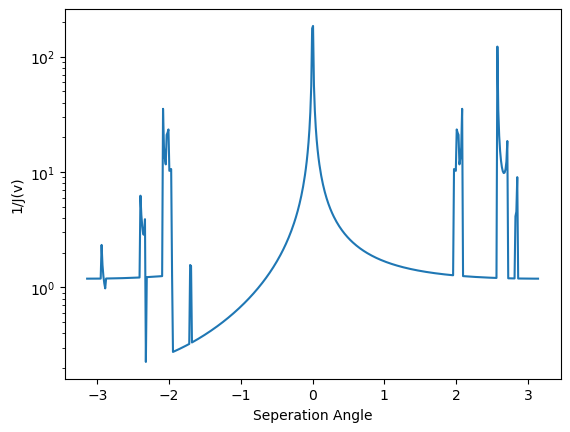

In [7]:
def jacobian_closed_form(v, Phi, rhat = [1, 0, 0]):
    """The derived closed-form result: |dv_infty/dv| = 1 - (Phi/D)^2."""
    #v = np.asarray(v, dtype=float)
    v2 = np.sum(v * v, axis = 1) #np.dot(v, v)
    u = np.sqrt(v2 - 2*Phi)
    vdotr = np.dot(v, rhat)
    D = u**2 + Phi - u*vdotr
    return np.abs(1 - (Phi/D)**2)


Phi = -grav(1)
#t = np.linspace(0, 1 * np.pi, 10000)
spd_loc = np.sqrt(2*Phi + spd*spd) #np.linspace(np.sqrt(2*Phi), 500, 1000)

#v = np.sqrt(2 * Phi / 10 * 16 + 2*Phi)
jac = jacobian_closed_form(v, Phi)

plt.clf()
plt.semilogy(phi[mask], 1/ jac[mask])
plt.xlabel("Seperation Angle")
plt.ylabel("1/J(v)")


Text(0, 0.5, '1/J(v)')

<Figure size 640x480 with 0 Axes>

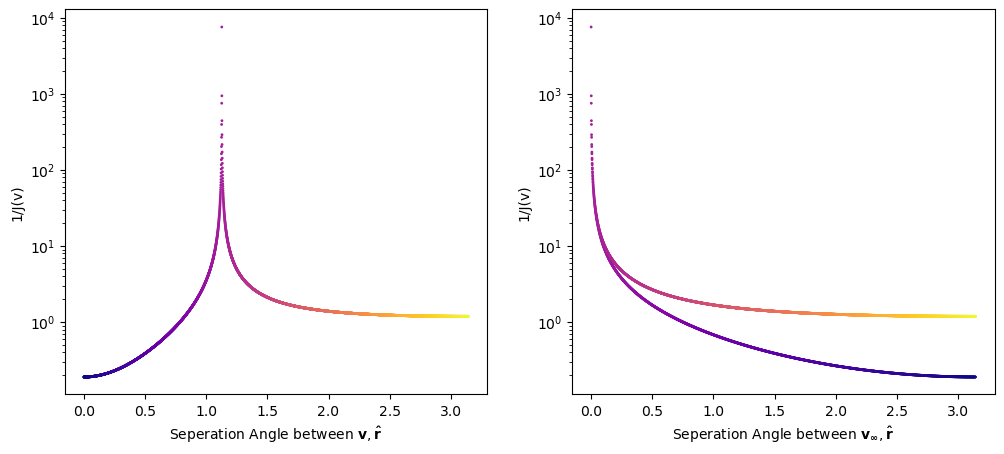

In [8]:
def jacobian_closed_form(v, Phi, theta):
    """The derived closed-form result: |dv_infty/dv| = 1 - (Phi/D)^2."""
    #v = np.asarray(v, dtype=float)
    v2 = v * v #np.sum(v * v, axis = 1) #np.dot(v, v)
    u = np.sqrt(v2 - 2*Phi)
    vdotr = v * np.cos(theta) #np.dot(v, rhat)
    D = u**2 + Phi - u*vdotr
    return np.abs(1 - (Phi/D)**2)


Phi = -grav(1)
#t = np.linspace(0, 1 * np.pi, 10000)
spd = 20
spd_loc = np.sqrt(2*Phi + spd*spd) #np.linspace(np.sqrt(2*Phi), 500, 1000)


z_vel = 0

r = np.array([1, 0, 0])

def v_inf(v, theta):
    #r = np.array([-1/sqrt(2), 1/sqrt(2), 0])
    d = np.sqrt(v*v + 2 * grav(r))

    vhat = np.array([np.cos(theta), np.sin(theta), z_vel])
    vhat = vhat / np.linalg.norm(vhat)

    vi = d * d * v * vhat\
        -  d * r / 1 * grav(r) \
        - d * v * vhat * (v * np.cos(theta))
    
    vi = vi / (d*d - grav(r) - d * v * np.cos(theta))
    
    return vi

v_i = []
phi = np.linspace(0, np.pi, 5000)
for t in phi:
    v_i.append(v_inf(spd_loc, t))

v_i = np.array(v_i)

v = np.column_stack([np.cos(phi), np.sin(phi), np.zeros_like(phi) + z_vel])
phi = np.sum(v * r, axis=1) / np.sqrt(np.sum(v*v, axis = 1))
phi = np.arccos(phi)

ang1 = np.sum(v_i * r, axis=1) / np.sqrt(np.sum(v_i*v_i, axis = 1))
ang = np.arccos(ang1)
#ang[ang1 < 0] = -ang[ang1 < 0]
#ang[100:] = -ang[100:]


#v = np.sqrt(2 * Phi / 10 * 16 + 2*Phi)
jac = jacobian_closed_form(spd_loc, Phi, phi)


plt.clf()
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].semilogy()
ax[0].scatter(phi, 1/jac, s= 1, c = np.arange(0, len(ang), 1), cmap= "plasma")
ax[0].set_xlabel(r"Seperation Angle between $\mathbf{v}, \mathbf{\hat{r}}$")
ax[0].set_ylabel("1/J(v)")

ax[1].semilogy()
ax[1].scatter(ang, 1/jac, s= 1, c = np.arange(0, len(ang), 1), cmap="plasma")
ax[1].set_xlabel(r"Seperation Angle between $\mathbf{v_\infty}, \mathbf{\hat{r}}$")
ax[1].set_ylabel("1/J(v)")


The reason i think we get two "curves" in the case of the second plot (where we plot the angle between the original stream velocity and position of earth), is due to the fact we are solving this in 3 dimensions. The stream itself will be a 2d plane wave of particles, and so the intersection between this plane wave and the plane of the earth's orbit will get boosted alot more. If we consider the plane of the earths orbit to be in x and y, then particles with a non-zero z position will be limited alot more in their position if their trajectories coincide with the earth's position. However, if the earths position is directly in line with the plane velocity then it doesn't matter as the particles with non-zero z will get boosted the same as particles purely in x-y plane. 

I.e., the actual density should be the two curves added on to each other. Furthermore, since we are only considering angles from 0 to pi, due to symmetry arguments, the density should be twice this? (actually not sure about the latter part) 

Text(0, 0.5, '1/J(v)')

<Figure size 640x480 with 0 Axes>

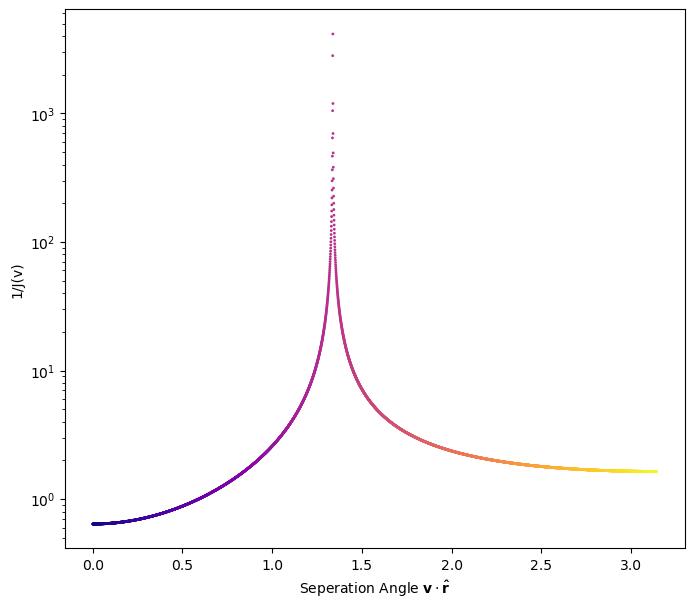

In [120]:
plt.clf()
plt.figure(figsize=(8, 7))

plt.semilogy()
plt.scatter(phi, 1/ jac, s= 1, c = np.arange(0, len(ang), 1), cmap= "plasma")

plt.xlabel(r"Seperation Angle $\mathbf{v} \cdot \mathbf{\hat{r}}$")
plt.ylabel("1/J(v)")